In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

In [51]:
evsc=qload('H_psi2')
evL1=qload('L50_psi2')
evL2=qload('L100_psi2')
evL3=qload('L200_psi2')
evLa1=qload('La50_psi2')
evLa2=qload('La100_psi2')
evLa3=qload('La200_psi2')

In [5]:
d=3
N=6
st1=basis(d,0)
st2=basis(d,1)
st3=basis(d,2)
psi0=st1           #初态
for i in range(N-1):
    psi0=tensor(psi0,st1)
    
psi1=tensor(st1,st1,st1,st2,st2,st1)
psi2=tensor(st1,st1,st2,st2,st3,st1)

tlist=np.linspace(0,30,300)

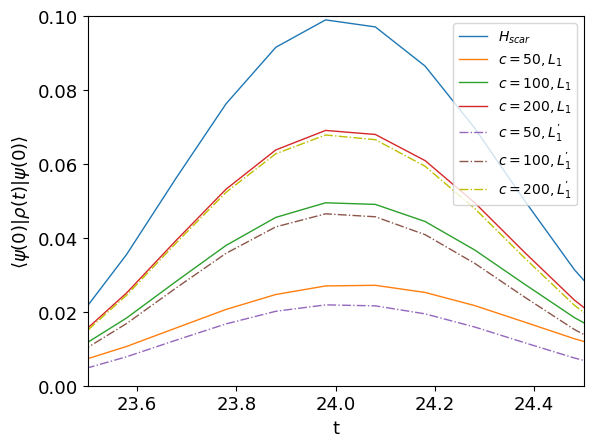

In [58]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, expect(psi2*psi2.dag(),evsc.states),linewidth=1.0, label=r'$H_{scar}$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL1.states),linewidth=1.0,label=r'$c=50,L_1$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL2.states),linewidth=1.0, label=r'$c=100,L_1$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL3.states),linewidth=1.0, label=r'$c=200,L_1$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa1.states),linewidth=1.0, linestyle='-.', label=r'$c=50,L^{’}_1$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa2.states),linewidth=1.0, linestyle='-.', label=r'$c=100,L^{’}_1$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa3.states),linewidth=1.0, linestyle='-.',color='y', label=r'$c=200,L^{’}_1$')
plt.xlim(23.5,24.5)
plt.ylim(0,0.1)
plt.xlabel('t',fontsize=13)
plt.ylabel(r'$\langle \psi(0) | \rho(t) |\psi(0) \rangle$',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
axes.legend(loc=1)
#plt.legend(framealpha=1)
plt.savefig('psi2sub')


In [59]:
evsc0=qload('H_psi0')
evsc1=qload('H_psi1')
evsc2=qload('H_psi2')
evL0=qload('L200_psi0')
evL1=qload('L200_psi1')
evL2=qload('L200_psi2')

In [62]:
t=len(tlist)
ovH1=np.zeros(t)
ovH2=np.zeros(t)
ovH3=np.zeros(t)
for i in range(t):
    ovH1[i]=expect(evL0.states[i],evsc0.states[i])
    ovH2[i]=expect(evL1.states[i],evsc1.states[i])
    ovH3[i]=expect(evL2.states[i],evsc2.states[i])

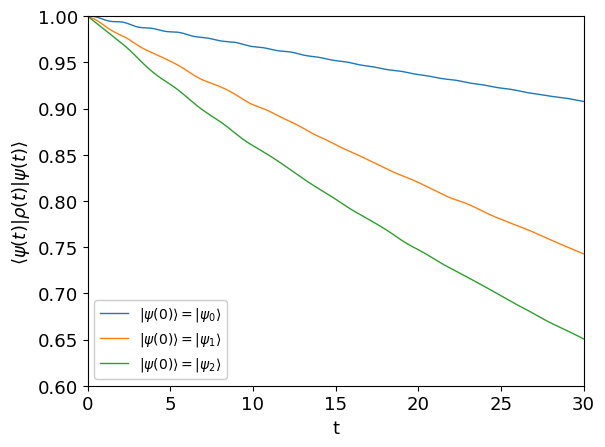

In [71]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, ovH1,linewidth=1.0, label=r'$|\psi(0)\rangle=|\psi_0\rangle$')
axes.plot(tlist, ovH2,linewidth=1.0, label=r'$|\psi(0)\rangle=|\psi_1\rangle$')
axes.plot(tlist, ovH3,linewidth=1.0, label=r'$|\psi(0)\rangle=|\psi_2\rangle$')
plt.xlabel('t',fontsize=13)
plt.ylabel(r'$\langle \psi(t) | \rho(t) |\psi(t) \rangle$',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0.6,1)
plt.xlim(0,30)
axes.legend(loc=3)
plt.legend(framealpha=1)
plt.savefig('ovlpHL.eps')